# Task 2: Predict Future Stock Prices

## Objective
The objective of this task is to predict the next day's closing stock price using historical stock market data and machine learning techniques.

## Dataset
Historical Apple (AAPL) stock data downloaded using the yfinance Python library.

## Model Used
Linear Regression

/tmp/ipykernel_1214/954169456.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(
[*********************100%***********************]  1 of 1 completed


(1006, 5)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1006 entries, 2020-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1006 non-null   float64
 1   (High, AAPL)    1006 non-null   float64
 2   (Low, AAPL)     1006 non-null   float64
 3   (Open, AAPL)    1006 non-null   float64
 4   (Volume, AAPL)  1006 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 47.2 KB


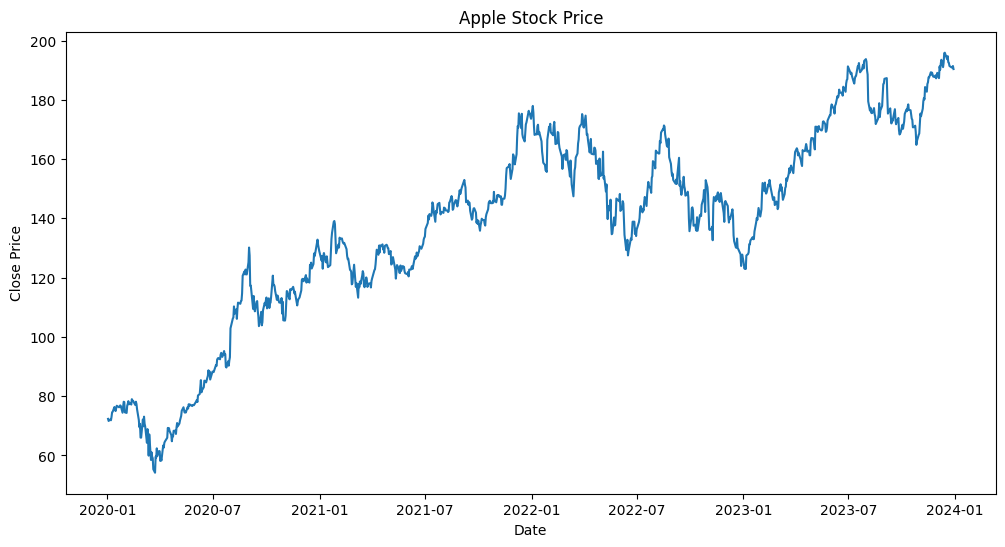

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
Target            0
dtype: int64
[149.83699149 149.61626604 153.08283285 152.80705409 154.31321429]
MAE: 1.6527005791221134
RMSE: 2.2219037493647495
R² Score: 0.9579011967752058


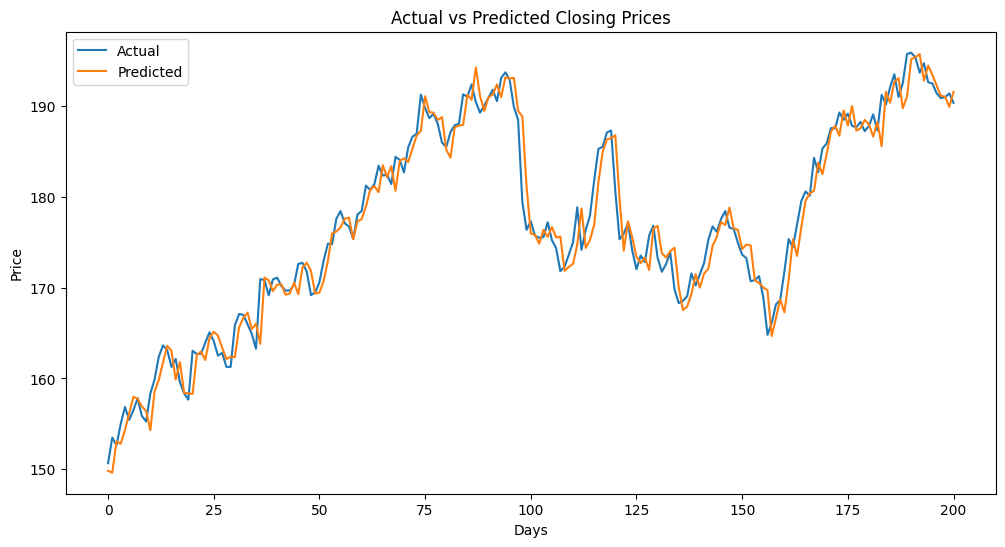

In [10]:
#import the libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
#download the stock data
#using apple stock data
stock = yf.download(
    "AAPL",
    start="2020-01-01",
    end="2024-01-01"
)
stock.head()
#exploring dataset
print(stock.shape)
stock.info()
print("\nSummary Statistics:")
print(stock.describe())
#visualizing
plt.figure(figsize=(12,6))
plt.plot(stock['Close'])
plt.title("Apple Stock Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()
#creating the target variable
stock['Target'] = stock['Close'].shift(-1)
# Drop rows with NaN values (which will be the last row due to shift(-1))
stock.dropna(inplace=True)
#remove missing values
print(stock.isnull().sum())
#selecting features and target
X = stock[['Open', 'High', 'Low', 'Volume']]
y = stock['Target']
#split the data
split = int(len(stock) * 0.8)
X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]
#model training
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
print(predictions[:5])
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)
r2 = r2_score(y_test, predictions)
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")
plt.title("Actual vs Predicted Closing Prices")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()

## Data Exploration

The dataset was explored using shape, information, and summary statistics to understand its structure and contents.

### Observation

The Apple stock price shows an overall upward trend over the selected period, with fluctuations reflecting market conditions.

## Model Evaluation

The model was evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics measure prediction accuracy and overall model performance.

## Final Insights

- Historical Apple stock data was successfully downloaded using yfinance.
- Open, High, Low, and Volume were used as predictive features.
- A Linear Regression model was trained to predict the next day's closing price.
- The model achieved an MAE of X.
- The model achieved an RMSE of Y.
- The model achieved an R² score of Z.
- The predicted prices closely followed the actual stock prices, indicating reasonable predictive performance.